<div align="center">
  <img src="../assets/uepb_logo.png" width="150">
  <br>
  <strong>Universidade Estadual da Paraíba (UEPB)</strong><br>
  <strong>Professor(a):</strong> Thiciany Matsudo Iwano<br>
  <strong>Alunos:</strong> Tarcio Elyakin Agra Diniz & Djhonatah Wesley Cavalcanti Alves<br>
  <strong>Série:</strong> Sistemas Lineares: teoria, interpretação geométrica e aplicações com Python<br>
</div>

---

# [Tutorial 05] Transformações Lineares e Matrizes

> **Pré-requisito:** [04] Geometria 3D e Independência Linear (`04_geometria_3d_e_independencia_linear.ipynb`)  
> **Próximo:** [06] Aplicação: Fluxo de Tráfego (`06_aplicacao_fluxo_trafego.ipynb`)

---

## Introdução

Até agora, tratamos os sistemas lineares como quebra-cabeças estáticos: encontrar valores de $x$ que satisfaçam uma igualdade. Mas a Álgebra Linear moderna vai muito além disso.

Neste tutorial, vamos mudar nossa perspectiva e ver as matrizes como **entidades dinâmicas**. Uma matriz $A$ não é apenas uma tabela de números; ela é uma **função** (ou transformação) que pega um vetor de um espaço e o "transporta" para outro.

Ao final deste tutorial, você será capaz de:
1. Compreender a definição de **Transformação Linear**.
2. Visualizar como uma matriz **rotaciona**, **estica** ou **projeta** o espaço.
3. Conectar os conceitos de **Núcleo** e **Imagem** à anatomia de uma função.
4. Identificar transformações **injetoras**, **sobrejetoras** e **isomorfismos**.

---

## 1. O que é uma Transformação Linear?

Uma **transformação linear** é uma função $T: V \to W$ entre dois espaços vetoriais que preserva as operações de adição de vetores e multiplicação por escalar.

Para quaisquer vetores $u, v \in V$ e escalar $\alpha$:
1. $T(u + v) = T(u) + T(v)$
2. $T(\alpha v) = \alpha T(v)$

No contexto de sistemas lineares $Ax = b$, a matriz $A$ de ordem $m \times n$ define uma transformação linear $T: \mathbb{R}^n \to \mathbb{R}^m$ através da multiplicação matricial:
$$T(x) = Ax$$

### Por que isso importa?
Resolver $Ax = b$ passa a ter uma interpretação funcional: estamos procurando todos os vetores $x$ no domínio que, ao passarem pela "máquina" $T$, resultam no vetor $b$ no contradomínio.

---

## 2. Matrizes como Transformações

Toda matriz representa uma transformação linear, e toda transformação linear entre espaços de dimensão finita pode ser representada por uma matriz (dadas as bases).

# 5. Visualização — Transformação Linear em 2D

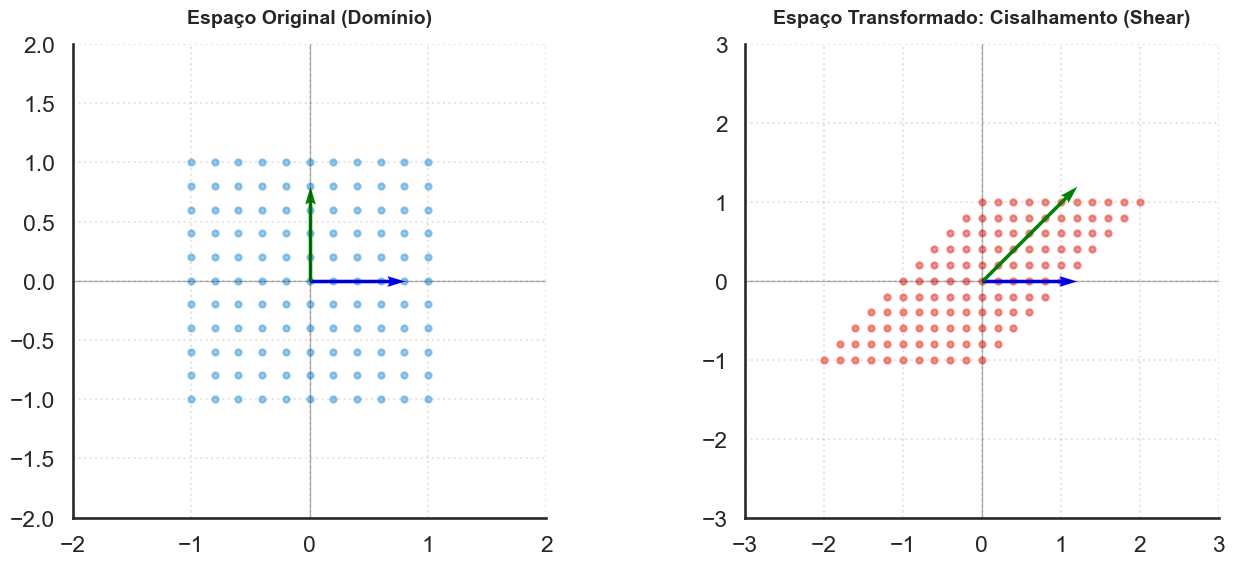

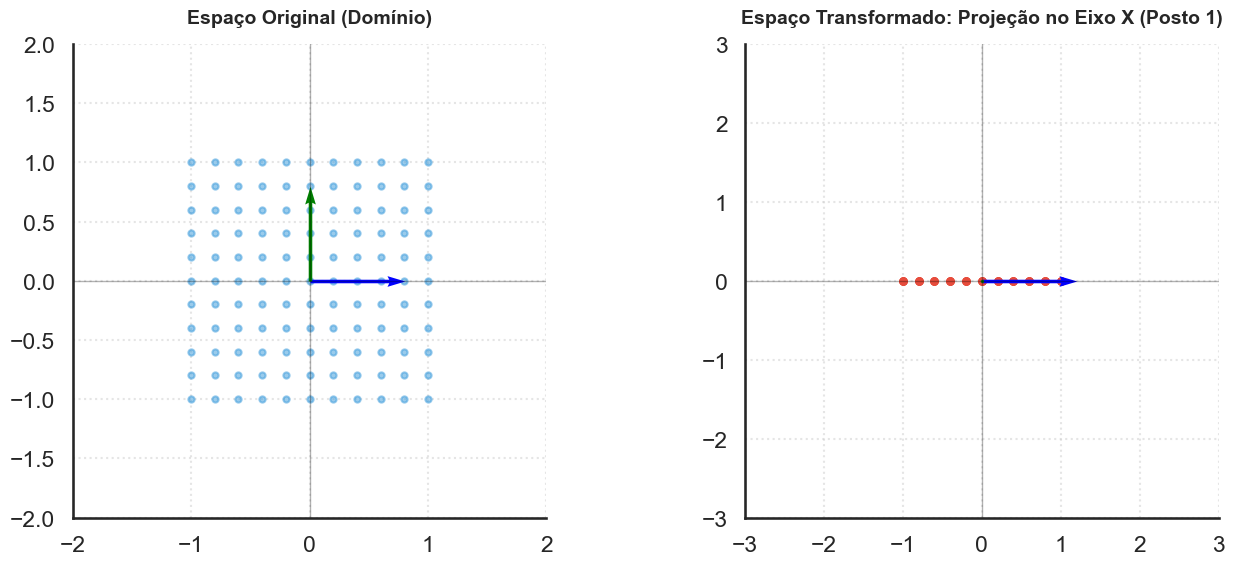

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo Seaborn 'white'
sns.set_theme(style="white", context="talk")

def plot_transformacao(A, titulo):
    # Criando uma grade de pontos
    x = np.linspace(-1, 1, 11)
    y = np.linspace(-1, 1, 11)
    X, Y = np.meshgrid(x, y)
    
    # Vetores originais
    pontos = np.vstack([X.flatten(), Y.flatten()])
    
    # Aplicando a transformação T(x) = Ax
    pontos_transf = A @ pontos
    
    X_transf = pontos_transf[0, :].reshape(X.shape)
    Y_transf = pontos_transf[1, :].reshape(Y.shape)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Paleta de cores
    cor_origem = "#3498db"
    cor_transf = "#e74c3c"
    
    # Plot Original
    ax1.set_title("Espaço Original (Domínio)", fontsize=14, fontweight='bold', pad=15)
    ax1.scatter(X, Y, color=cor_origem, alpha=0.5, s=20)
    ax1.quiver(0, 0, 1, 0, color='blue', scale=5, label='i')
    ax1.quiver(0, 0, 0, 1, color='green', scale=5, label='j')
    ax1.axhline(0, color='black', lw=1, alpha=0.3)
    ax1.axvline(0, color='black', lw=1, alpha=0.3)
    ax1.set_xlim(-2, 2); ax1.set_ylim(-2, 2); ax1.set_aspect('equal')
    ax1.grid(True, linestyle=':', alpha=0.5)
    
    # Plot Transformado
    ax2.set_title(f"Espaço Transformado: {titulo}", fontsize=14, fontweight='bold', pad=15)
    ax2.scatter(X_transf, Y_transf, color=cor_transf, alpha=0.6, s=20)
    
    # Transformando os vetores da base
    i_transf = A @ np.array([1, 0])
    j_transf = A @ np.array([0, 1])
    
    ax2.quiver(0, 0, i_transf[0], i_transf[1], color='blue', scale=5, label="T(i)")
    ax2.quiver(0, 0, j_transf[0], j_transf[1], color='green', scale=5, label="T(j)")
    
    ax2.axhline(0, color='black', lw=1, alpha=0.3)
    ax2.axvline(0, color='black', lw=1, alpha=0.3)
    ax2.set_xlim(-3, 3); ax2.set_ylim(-3, 3); ax2.set_aspect('equal')
    ax2.grid(True, linestyle=':', alpha=0.5)
    
    sns.despine(ax=ax1); sns.despine(ax=ax2)
    plt.tight_layout()
    plt.show()

# Exemplo: Cisalhamento (Shear)
A_shear = np.array([[1, 1], [0, 1]])
plot_transformacao(A_shear, "Cisalhamento (Shear)")

# Exemplo: Projeção (Posto 1)
A_proj = np.array([[1, 0], [0, 0]])
plot_transformacao(A_proj, "Projeção no Eixo X (Posto 1)")

---

## 3. Núcleo (Kernel) e Imagem

Estes dois subespaços são fundamentais para entender a solução de sistemas.

### Núcleo (Kernel)
O **núcleo** de $T$, denotado por $ker(T)$ ou $null(A)$, é o conjunto de todos os vetores $x$ que são mapeados no vetor nulo:
$$ker(T) = \{x \in V \mid T(x) = \mathbf{0}\}$$
*   **Conexão com Sistemas:** O núcleo é o conjunto solução do sistema homogêneo $Ax = \mathbf{0}$.
*   Se o núcleo contém apenas o vetor zero, a transformação é **injetora**.

### Imagem
A **imagem** de $T$, denotada por $im(T)$ ou $col(A)$, é o conjunto de todos os vetores $b$ que podem ser obtidos a partir de algum $x$:
$$im(T) = \{T(x) \mid x \in V\}$$
*   **Conexão com Sistemas:** O sistema $Ax = b$ tem solução se, e somente se, $b$ pertence à imagem de $T$.
*   A imagem é o espaço gerado pelas colunas de $A$.

---

## 4. Teorema da Dimensão (Posto-Nulidade)

Um dos resultados mais importantes da Álgebra Linear relaciona as dimensões desses espaços:
$$\dim(V) = \dim(ker(T)) + \dim(im(T))$$
Ou, em termos de matrizes $A_{m \times n}$:
$$n = \text{nulidade}(A) + \text{posto}(A)$$

Onde:
*   **n:** número de colunas (dimensão do domínio).
*   **posto (rank):** dimensão da imagem.
*   **nulidade (nullity):** dimensão do núcleo.

---

## 5. Implementação: Calculando Núcleo e Imagem com SymPy


In [2]:
import sympy as sp

# Criando uma matriz com dependência linear
M = sp.Matrix([
    [1, 2, 3],
    [2, 4, 6],
    [4, 5, 6]
])

print("Matriz M:")
sp.pprint(M)

# 1. Calculando a Imagem (Espaço Coluna)
# O método columnspace() retorna uma base para a imagem
imagem = M.columnspace()
print("\nBase para a Imagem (col(M)):")
for v in imagem:
    sp.pprint(v)

# 2. Calculando o Núcleo (Kernel)
# O método nullspace() retorna uma base para o núcleo
nucleo = M.nullspace()
print("\nBase para o Núcleo (null(M)):")
for v in nucleo:
    sp.pprint(v)

# 3. Verificando o Teorema da Dimensão
n = M.cols
posto = len(imagem)
nulidade = len(nucleo)

print(f"\nDimensão do Domínio (n): {n}")
print(f"Posto (rank): {posto}")
print(f"Nulidade (nullity): {nulidade}")
print(f"Verificação: {nulidade} + {posto} = {nulidade + posto}")

Matriz M:
⎡1  2  3⎤
⎢       ⎥
⎢2  4  6⎥
⎢       ⎥
⎣4  5  6⎦

Base para a Imagem (col(M)):
⎡1⎤
⎢ ⎥
⎢2⎥
⎢ ⎥
⎣4⎦
⎡2⎤
⎢ ⎥
⎢4⎥
⎢ ⎥
⎣5⎦

Base para o Núcleo (null(M)):
⎡1 ⎤
⎢  ⎥
⎢-2⎥
⎢  ⎥
⎣1 ⎦

Dimensão do Domínio (n): 3
Posto (rank): 2
Nulidade (nullity): 1
Verificação: 1 + 2 = 3


---

## 6. Isomorfismos e Invertibilidade

Uma transformação linear $T: V \to V$ é um **isomorfismo** se for invertível (bijetora). 
Para matrizes quadradas $A$, isso equivale a dizer que:
1. $A$ é invertível ($A^{-1}$ existe).
2. $det(A) \neq 0$.
3. O núcleo é $\{0\}$ (nulidade = 0).
4. O posto é igual a $n$ (posto cheio).

Nesse caso, o sistema $Ax = b$ sempre tem uma **solução única** $x = A^{-1}b$ para qualquer $b$.

---

## 7. Visualização 2D: Transformações no Plano

Vamos visualizar como uma matriz "deforma" o espaço.


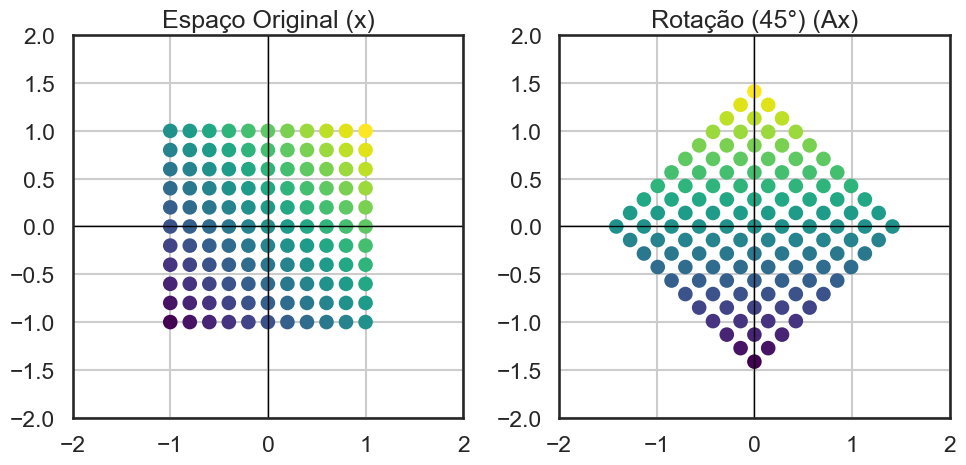

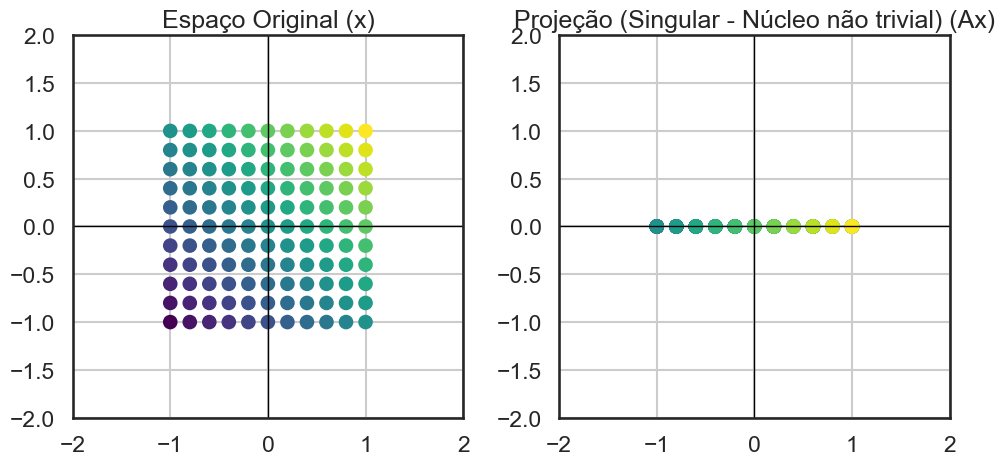

In [3]:
def plot_transformation(A, title="Transformação Linear"):
    # Criando uma grade de pontos
    x = np.linspace(-1, 1, 11)
    y = np.linspace(-1, 1, 11)
    xx, yy = np.meshgrid(x, y)
    
    # Vetores originais
    xy = np.vstack([xx.flatten(), yy.flatten()])
    
    # Aplicando a transformação
    xy_transformed = A @ xy
    
    # Plot
    plt.figure(figsize=(10, 5))
    
    # Espaço Original
    plt.subplot(1, 2, 1)
    plt.scatter(xy[0], xy[1], c=xy[0]+xy[1], cmap='viridis')
    plt.grid(True)
    plt.title("Espaço Original (x)")
    plt.axhline(0, color='black', lw=1)
    plt.axvline(0, color='black', lw=1)
    plt.xlim(-2, 2); plt.ylim(-2, 2)
    
    # Espaço Transformado
    plt.subplot(1, 2, 2)
    plt.scatter(xy_transformed[0], xy_transformed[1], c=xy[0]+xy[1], cmap='viridis')
    plt.grid(True)
    plt.title(f"{title} (Ax)")
    plt.axhline(0, color='black', lw=1)
    plt.axvline(0, color='black', lw=1)
    plt.xlim(-2, 2); plt.ylim(-2, 2)
    
    plt.tight_layout()
    plt.show()

# Testando com uma matriz de rotação de 45 graus
theta = np.radians(45)
c, s = np.cos(theta), np.sin(theta)
R = np.array([[c, -s], [s, c]])

plot_transformation(R, title="Rotação (45°)")

# Testando com uma matriz singular (projeção no eixo x)
P = np.array([[1, 0], [0, 0]])
plot_transformation(P, title="Projeção (Singular - Núcleo não trivial)")

---
## Próximo Passo

Parabéns! Você completou a base teórica fundamental de Sistemas Lineares e Transformações. Você agora possui as ferramentas para entender não apenas *como* resolver um sistema, mas *o que* ele representa no tecido do espaço vetorial.

A partir daqui, vamos aplicar todo esse conhecimento em problemas reais. No próximo tutorial, vamos modelar o fluxo de veículos em uma cidade usando tudo o que aprendemos sobre matrizes e sistemas.

👉 **[Ir para o Tutorial 06: Aplicação: Fluxo de Tráfego](./06_aplicacao_fluxo_trafego.ipynb)**
